---
tags: [integration, optimization, variational]
---

# QURI Partsサポート

このページでは、具体的な最適化問題を題材に、Qamomileの[QURI Parts](https://quri-parts.qunasys.com/)バックエンドを紹介します。小さなMaxCutインスタンスを`BinaryModel.from_ising`でIsing問題としてモデル化し、`QAOAConverter`でQAOAアンザッツへコンパイルして、`QuriPartsTranspiler` / `QuriPartsExecutor`を介して実行します。`QuriPartsExecutor`は、既定で高速なC++製状態ベクトルシミュレータである[Qulacs](https://docs.qulacs.org/)を使用するため、追加の設定なしにローカルCPU上で以下の例を実行できます。

In [1]:
# 最新のQamomileをQURI Partsオプション付きでpipからインストールします。
# !pip install "qamomile[quri_parts]"

## MaxCut問題

QURI Parts連携の説明に集中するため、[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じ5ノードの小さなグラフを再利用します。$\sum_{(i,j) \in E}(1 - s_i s_j)/2$を最大化することは、定数項を除いて、反強磁性Isingハミルトニアン$H_C = \sum_{(i,j) \in E} s_i s_j$を*最小化*することと等価です。重みなしMaxCutではすべての$J_{ij} = 1$、$h_i = 0$なので、これらの係数をそのまま`BinaryModel.from_ising`に渡します。

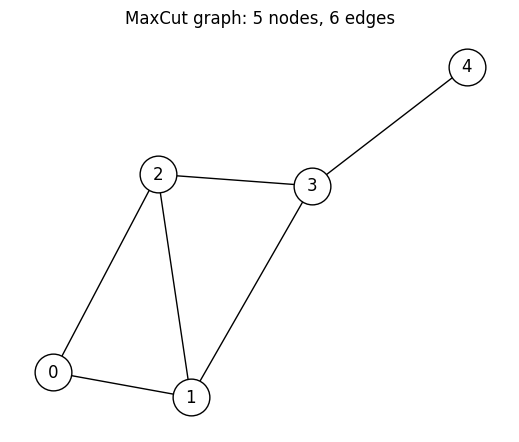

In [2]:
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qamomile.optimization.binary_model import BinaryModel

G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
spin_model = BinaryModel.from_ising(linear={}, quad=ising_quad)

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## `QuriPartsTranspiler`によるQAOAのコンパイル

`QAOAConverter`は`BinaryModel`(またはOMMXインスタンス)を受け取り、`get_cost_hamiltonian()`でPauli-Zコストハミルトニアンを公開し、`transpile(transpiler, p=p)`で測定を末尾に持つQAOAサンプリング用kernelを生成します。`QuriPartsTranspiler()`を使うには、transpiler引数を差し替えるだけで十分です。`QAOAConverter`は、Qamomileがサポートする任意のバックエンドで利用できます。

In [3]:
from qamomile.optimization.qaoa import QAOAConverter
from qamomile.quri_parts import QuriPartsExecutor, QuriPartsTranspiler

p = 3  # QAOA層数

converter = QAOAConverter(spin_model)
cost_hamiltonian = converter.get_cost_hamiltonian()
print("Cost Hamiltonian:")
print(cost_hamiltonian)

transpiler = QuriPartsTranspiler()
executor = QuriPartsExecutor()

executable = converter.transpile(transpiler, p=p)

Cost Hamiltonian:
Hamiltonian((Z0, Z1): 1.0, (Z0, Z2): 1.0, (Z1, Z2): 1.0, (Z1, Z3): 1.0, (Z2, Z3): 1.0, (Z3, Z4): 1.0)


生成されたQURI Parts回路を確認すると、linear-mappedなparametric回路であること、そして$2p$個のQAOA角度(`gammas[0..p-1]`、`betas[0..p-1]`)が名前付きランタイムパラメータとして残っていることが分かります。

In [4]:
quri_circuit = executable.get_first_circuit()
assert quri_circuit is not None  # transpile()はここで必ず1つの量子セグメントを生成する
print(type(quri_circuit).__name__)
print("qubit_count    :", quri_circuit.qubit_count)
print("parameter_count:", quri_circuit.parameter_count)

LinearMappedParametricQuantumCircuit
qubit_count    : 5
parameter_count: 6


実行時のオブジェクトは、QURI Partsのlinear-mappedなparametric回路です(ランタイムでは`LinearMappedParametricQuantumCircuit`、公開APIでは`LinearMappedUnboundParametricQuantumCircuit`という別名)。各ランタイムパラメータのスロットは実行時までunboundのままなので、`gammas` / `betas`のバインドはQURI Parts側での回路の作り直しではなく、安価な数値更新になります。問題の構造(Ising係数、量子ビット数、層数)はコンパイル時に固定され、ランタイム入力として残るのは変分角度だけです。

## `QuriPartsExecutor`によるQAOAサンプリング

`executable.sample(executor, bindings=..., shots=...)`は`SampleJob`を返します。`.result()`で得られる`SampleResult`は、converterでspinドメイン(+1 / -1)の`BinarySampleSet`へデコードできます。そのため、追加の変換なしにそのままcut辺を数えられます。`QuriPartsExecutor()`はデフォルトでQulacs状態ベクトルシミュレータ上で動作します。

In [5]:
rng = np.random.default_rng(42)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = converter.decode_to_binary_sampleset(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")

Mean energy at random init: -0.6610


## QAOAパラメータの最適化

同じ`executable`を異なる`(gammas, betas)`で繰り返し呼び出すのが、QAOA最適化ループの基本的な使い方です。`converter.transpile()`を1回呼び、その後は`executable.sample()`を何度も呼び出します。以下では、sampleとdecodeの処理をSciPyの`minimize`で包みます。古典オプティマイザが`(gammas, betas)`を更新してサンプリングしたIsingエネルギーの平均を最小化する一方、各反復では同じ`executable`と`QuriPartsExecutor`を再利用します。

In [6]:
from scipy.optimize import minimize

cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = converter.decode_to_binary_sampleset(result).energy_mean()
    cost_history.append(energy)
    return energy


res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")

Optimized mean energy: -2.6890
Optimal gammas       : [1.5432, -0.8962, 1.1659]
Optimal betas        : [0.0568, -1.9296, 1.39]


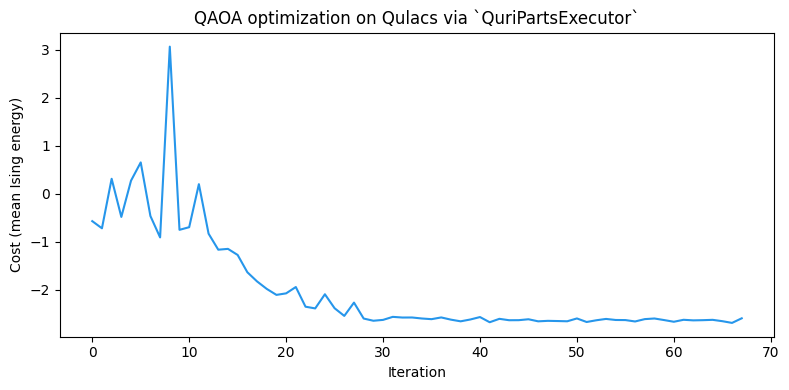

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on Qulacs via `QuriPartsExecutor`")
plt.tight_layout()
plt.show()

`QuriPartsExecutor`が使うQulacs samplerはショットごとのRNGにseedを設定しないため、最適化軌跡や最終エネルギーは実行ごとに多少変動します。それでも、この5ノードグラフ上の$H_C$の基底状態エネルギー付近までは収束するはずです。上で得た最適パラメータ(`opt_gammas`、`opt_betas`)を、以降の例でも使います。

## 期待値: unbound parametric回路とbound回路のdispatch

`QuriPartsExecutor.estimate_expectation(circuit, hamiltonian, param_values)`は、QURI Partsネイティブな期待値評価のエントリポイントです。受け取った**回路の状態**に応じて、内部で2つの異なるQURI Parts estimatorを自動的に切り替えます。

- **Unbound parametricな回路**: `transpile()`が生成したlinear-mapped回路はまだフリーパラメータを持っています。QURI Partsの`apply_circuit`がこれを`ParametricCircuitQuantumState`としてラップし、executorはQURI Partsの**parametric estimator**に処理を回します。この経路では、評価時に`param_values`を使ってパラメータをバインドします。
- **Boundまたは非parametricな回路**: 一度パラメータがバインドされると(例えば`circuit.bind_parameters([...])`を呼ぶと)、同じ`apply_circuit`は`GeneralCircuitQuantumState`を生成します。executorはQURI Partsの**non-parametric estimator**にフォールバックし、`param_values`は無視されます。

どちらの経路が選ばれるかを知っておく意味は、2つのestimatorのコスト特性が異なることにあります。タイトな最適化ループの中では、反復ごとに回路をコピーしなくてよいparametric estimatorが適しています。一方、パラメータがすでに具体化されているなら、non-parametric estimatorのほうがparametric固有のオーバーヘッドを避けられます。

QURI Partsは回路レベルでは`measure`をno-opとして扱うため、`converter.transpile()`が出すparametric回路はそのままQAOA状態$|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle$の準備を表します。これをコストハミルトニアンと一緒に`estimate_expectation`へ渡せば、$\langle H_C \rangle$をサンプリングノイズなしで解析的に計算できます。したがってQAOAオプティマイザの中では、同じ回路のまま`executable.sample()`+decodeを`executor.estimate(circuit, hamiltonian, params=...)`に置き換えられます。

両方のestimator経路を直接試したいときは、converterのコストハミルトニアンからQURI PartsのOperatorを構築し、それぞれの回路に対して`estimate_expectation`を呼びます。

In [8]:
from qamomile.quri_parts.observable import hamiltonian_to_quri_operator

quri_H = hamiltonian_to_quri_operator(cost_hamiltonian)

# converter.transpile()直後のunbound parametric回路
unbound_circuit = executable.get_first_circuit()
assert unbound_circuit is not None
print(f"unbound type           : {type(unbound_circuit).__name__}")
print(f"unbound parameter_count: {unbound_circuit.parameter_count}")

# QURI Partsはランタイムパラメータを「回路に登録された順序のフラットなリスト」
# として要求します。登録順は回路emit時のfirst-use順なので、QAOAでは
# gammas[0], betas[0], gammas[1], betas[1], ... と層ごとに交互の順になります。
# 「全gammasに続いて全betas」ではない点に注意してください。
# 規約を推測しなくて済むよう、executableから順序を読み、lookupでフラット化します。
named_values = {f"gammas[{i}]": opt_gammas[i] for i in range(p)}
named_values.update({f"betas[{i}]": opt_betas[i] for i in range(p)})
flat_params = [named_values[name] for name in executable.parameter_names]
print(f"circuit parameter order: {executable.parameter_names}")

# QURI Partsのネイティブbinderで同じ数値を手動でバインド
bound_circuit = unbound_circuit.bind_parameters(flat_params)
print(f"bound   type           : {type(bound_circuit).__name__}")

# 経路1: unbound -> parametric estimator。param_valuesが消費されます
energy_unbound = executor.estimate_expectation(
    unbound_circuit, quri_H, flat_params
)

# 経路2: bound -> non-parametric estimator。param_valuesは無視されます
energy_bound = executor.estimate_expectation(bound_circuit, quri_H, [])

print(f"parametric  estimator: {energy_unbound:+.10f}")
print(f"non-param.  estimator: {energy_bound:+.10f}")
assert np.isclose(energy_unbound, energy_bound, atol=1e-10)

unbound type           : LinearMappedParametricQuantumCircuit
unbound parameter_count: 6
circuit parameter order: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
bound   type           : ImmutableBoundParametricQuantumCircuit
parametric  estimator: -2.6274403014
non-param.  estimator: -2.6274403014


両経路は数値精度の範囲で一致します。同じQAOA状態を同じIsingコストハミルトニアンに対して評価しているからです。さらに、最適化後のパラメータにおけるこのノイズなしの期待値は、先ほど出力した最適化済みの標本平均エネルギーともショットノイズの範囲で一致するはずです。このdispatchはQamomileの`executor.estimate()`インターフェースの中に隠れているので、利用者は通常意識せずに済みます。自分でQURI Parts回路を直接扱う事情があるときだけ、`estimate_expectation`を直接呼べば十分です。

`executor.estimate(circuit, hamiltonian, params=...)`は1段上のバリアントです。`qamomile.observable.Hamiltonian`を直接受け取り、内部で自動変換してから`estimate_expectation`に委譲します。

In [9]:
energy_via_estimate = executor.estimate(
    unbound_circuit, cost_hamiltonian, params=flat_params
)
print(f"executor.estimate     : {energy_via_estimate:+.10f}")
assert np.isclose(energy_via_estimate, energy_unbound, atol=1e-10)

executor.estimate     : -2.6274403014


## samplerとestimatorのカスタマイズ

`QuriPartsExecutor()`は、初回利用時にデフォルトのQulacs samplerとparametric estimatorを遅延生成します。別のシミュレータ、ノイズを考慮したsampler、リモートデバイスなど、別のQURI Partsバックエンドを差し込むには、`QuriPartsTranspiler.executor(sampler=..., estimator=...)`からsamplerとestimatorを渡すか、`QuriPartsExecutor`を直接インスタンス化します。

```python
from quri_parts.qulacs.sampler import create_qulacs_vector_sampler
from quri_parts.qulacs.estimator import create_qulacs_vector_parametric_estimator

custom_executor = transpiler.executor(
    sampler=create_qulacs_vector_sampler(),
    estimator=create_qulacs_vector_parametric_estimator(),
)
```

カスタムexecutorは、上で使った`executor`をそのまま差し替えるだけで動きます。samplerを変えてもkernelをトランスパイルし直す必要はありません。executableが回路を持ち、executorがシミュレーションバックエンドを持つためです。

## まとめ

- `BinaryModel.from_ising` + `QAOAConverter`はMaxCutに対するspinドメインのレシピです。converterにIsing係数を渡し、`converter.transpile(QuriPartsTranspiler(), p=p)`を呼べば、linear-mappedなparametric QURI Parts回路を内包する`ExecutableProgram`としてQAOAサンプリング回路が得られます。
- `QuriPartsExecutor`は、デフォルトのQulacs状態ベクトルシミュレータに対して、QAOA風サンプリングのための`executable.sample()`と、ノイズなしの期待値評価のための`executor.estimate(...)`の両方をサポートします。
- `estimate_expectation`は、入力回路にフリーパラメータが残っているかどうかに応じて、QURI Partsのparametric estimatorとnon-parametric estimatorを切り替えます。通常は`executor.estimate()`がdispatchを隠しますが、Qamomileの高水準インターフェースの外で連携するときには直接呼び出すこともできます。
- カスタムのsamplerやestimatorはexecutor側から差し替えられ、kernelをトランスパイルし直す必要はありません。